In [3]:
import pandas as pd
import numpy as np
import re

In [4]:
df=pd.read_csv("../Data/manualTrain.csv")
print(df.columns)
print(df.shape)

Index(['question1', 'question2', 'is_duplicate', 'q1_len', 'q2_len',
       'q1_num_words', 'q2_num_words', 'word_common', 'word_total',
       'word_share', 'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min',
       'ctc_max', 'last_word_eq', 'first_word_eq', 'abs_len_diff', 'mean_len',
       'longest_substr_ratio', 'fuzz_ratio', 'fuzz_partial_ratio',
       'token_sort_ratio', 'token_set_ratio', 'q1_freq', 'q2_freq',
       'noun_ratio', 'verb_ratio', 'cosine_sim', 'ner_overlap', 'jaccard_sim'],
      dtype='object')
(404290, 32)


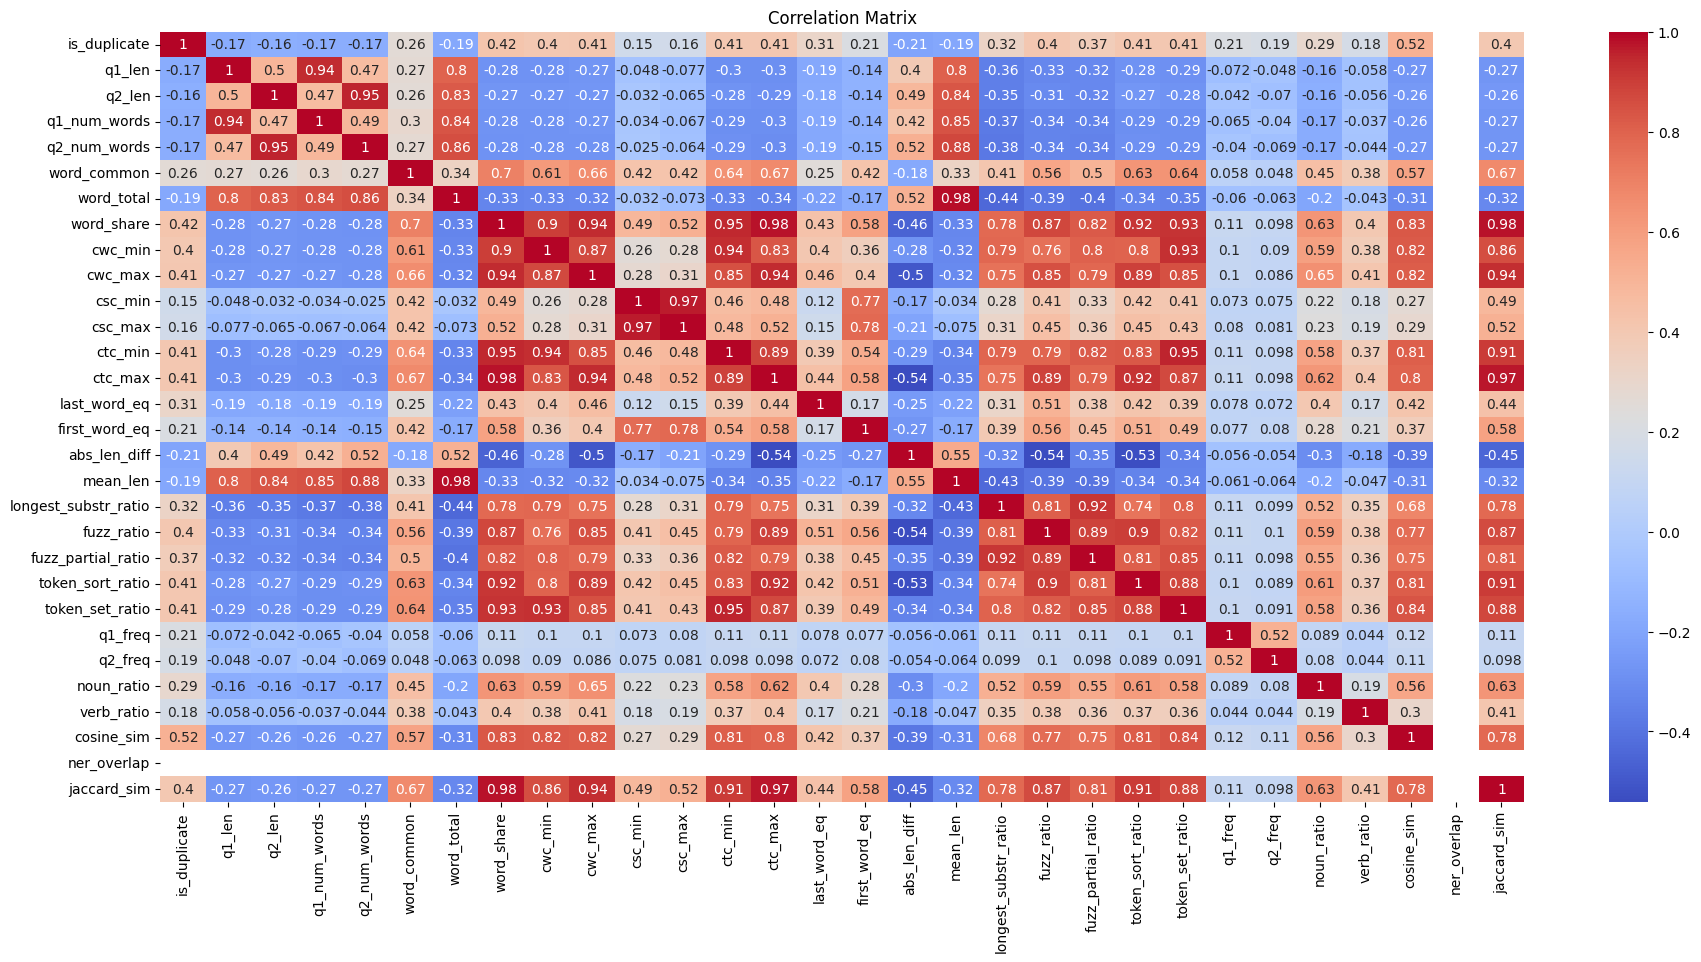

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(22, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [6]:
# 1. Calculate the correlation matrix
correlations = df.corr(numeric_only=True)['is_duplicate'].abs().sort_values(ascending=False)

# 2. Identify features with very low correlation (e.g., less than 0.02)
# You can adjust this threshold based on your results
threshold = 0.1
features_to_drop = correlations[correlations < threshold].index.tolist()

# 3. Drop them from your training data
df_final = df.drop(columns=features_to_drop)

print(f"Features kept: {len(df_final.columns)}")
print(f"Features dropped: {features_to_drop}")

Features kept: 32
Features dropped: []


In [7]:
print(df['is_duplicate'].value_counts() )
#to balance the dataset we can use undersampling or oversampling techniques. We will use undersampling here to balance the dataset.
# Separate the majority and minority classes
majority_class = df_final[df_final['is_duplicate'] == 0]
minority_class = df_final[df_final['is_duplicate'] == 1]
# Undersample the majority class
majority_class_undersampled = majority_class.sample(n=len(minority_class), random_state=42)
# Combine the undersampled majority class with the minority class
balanced_df = pd.concat([majority_class_undersampled, minority_class])
# Shuffle the balanced dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
print(balanced_df['is_duplicate'].value_counts())

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
1    149263
0    149263
Name: count, dtype: int64


In [11]:
import optuna
import joblib
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV

balanced_df['question1'] = balanced_df['question1'].fillna('')
balanced_df['question2'] = balanced_df['question2'].fillna('')
balanced_df['question1'] = balanced_df['question1'].astype(str)
balanced_df['question2'] = balanced_df['question2'].astype(str)

features_kept=[col for col in balanced_df.columns if col not in ['question1', 'question2', 'is_duplicate'] ]
x_train, x_test, y_train, y_test = train_test_split(balanced_df.drop(columns=['is_duplicate']), balanced_df['is_duplicate'], test_size=0.2, random_state=42)


def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['RandomForest', 'XGBoost', 'LogisticRegression', 'LinearSVC'])
    
    ngram_choice = trial.suggest_categorical('ngram', [1, 2])
    max_feat = trial.suggest_int('max_features', 5000, 10000, step=1000)

    if classifier_name == 'RandomForest':
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int('rf_n_estimators', 100, 300),
            max_depth=trial.suggest_int('rf_max_depth', 10, 30),
            n_jobs=-1
        )
    elif classifier_name == 'XGBoost':
        model = XGBClassifier(
            n_estimators=trial.suggest_int('xgb_n_estimators', 100, 500),
            learning_rate=trial.suggest_float('xgb_lr', 1e-3, 0.3, log=True),
            max_depth=trial.suggest_int('xgb_max_depth', 3, 10),
            eval_metric='logloss'
        )
    elif classifier_name == 'LogisticRegression':
        model = LogisticRegression(
            C=trial.suggest_float('lr_c', 1e-3, 10, log=True),
            max_iter=10000
        )
    else:
        base_svc = LinearSVC(C=trial.suggest_float('svc_c', 1e-3, 10, log=True), dual=False)
        model = CalibratedClassifierCV(base_svc)

    text_transformer = Pipeline([
        ('vect', CountVectorizer(ngram_range=(1, ngram_choice), max_features=max_feat)),
        ('tfidf', TfidfTransformer())
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('q1_text', text_transformer, 'question1'),
        ('q2_text', text_transformer, 'question2'),
        ('manual', 'passthrough', features_kept)
    ])

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    score = cross_val_score(pipeline, x_train, y_train, cv=2, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

best_p = study.best_params
final_ngram = (1, best_p['ngram'])
print("Best Hyperparameters:", best_p)
print("Best Accuracy:", study.best_value)
print(f"Best Model Type: {best_p['classifier']}")
print(f"Best N-gram Range: {final_ngram}")

if best_p['classifier'] == 'RandomForest':
    final_model = RandomForestClassifier(n_estimators=best_p['rf_n_estimators'], max_depth=best_p['rf_max_depth'])
elif best_p['classifier'] == 'XGBoost':
    final_model = XGBClassifier(n_estimators=best_p['xgb_n_estimators'], learning_rate=best_p['xgb_lr'], max_depth=best_p['xgb_max_depth'])
elif best_p['classifier'] == 'LogisticRegression':
    final_model = LogisticRegression(C=best_p['lr_c'], max_iter=1000)
else:
    final_model = CalibratedClassifierCV(LinearSVC(C=best_p['svc_c'], dual=False))

final_text_transformer = Pipeline([
    ('vect', CountVectorizer(ngram_range=final_ngram, max_features=best_p['max_features'])),
    ('tfidf', TfidfTransformer())
])

final_preprocessor = ColumnTransformer(transformers=[
    ('q1_text', final_text_transformer, 'question1'),
    ('q2_text', final_text_transformer, 'question2'),
    ('manual', 'passthrough', features_kept)
])

final_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('classifier', final_model)
])

final_pipeline.fit(x_train, y_train)
joblib.dump(final_pipeline, 'quora_final_pipeline.pkl')

print(f"Best Model Type: {best_p['classifier']}")
print(f"Best Accuracy: {study.best_value}")

[I 2026-04-07 22:35:42,542] A new study created in memory with name: no-name-151b51f2-8259-4198-9df9-05447c8dfade
[I 2026-04-07 22:35:58,019] Trial 0 finished with value: 0.7696047232225107 and parameters: {'classifier': 'RandomForest', 'ngram': 1, 'max_features': 5000, 'rf_n_estimators': 130, 'rf_max_depth': 11}. Best is trial 0 with value: 0.7696047232225107.
[I 2026-04-07 22:36:21,968] Trial 1 finished with value: 0.7545892303827151 and parameters: {'classifier': 'RandomForest', 'ngram': 2, 'max_features': 6000, 'rf_n_estimators': 154, 'rf_max_depth': 10}. Best is trial 0 with value: 0.7696047232225107.
[I 2026-04-07 22:46:03,078] Trial 2 finished with value: 0.8564944309521816 and parameters: {'classifier': 'XGBoost', 'ngram': 2, 'max_features': 6000, 'xgb_n_estimators': 389, 'xgb_lr': 0.005558034820240132, 'xgb_max_depth': 7}. Best is trial 2 with value: 0.8564944309521816.
[I 2026-04-07 22:48:56,880] Trial 3 finished with value: 0.8679968176869609 and parameters: {'classifier': '

Best Hyperparameters: {'classifier': 'XGBoost', 'ngram': 1, 'max_features': 9000, 'xgb_n_estimators': 496, 'xgb_lr': 0.21850804319638362, 'xgb_max_depth': 4}
Best Accuracy: 0.8679968176869609
Best Model Type: XGBoost
Best N-gram Range: (1, 1)
Best Model Type: XGBoost
Best Accuracy: 0.8679968176869609


BAG OF WORDS

In [12]:
y_pred = final_pipeline.predict(x_test)
print("classification_report:\n", classification_report(y_test, y_pred))
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("precision_score:", precision_score(y_test, y_pred))
print("recall_score:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))


classification_report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87     29940
           1       0.85      0.89      0.87     29766

    accuracy                           0.87     59706
   macro avg       0.87      0.87      0.87     59706
weighted avg       0.87      0.87      0.87     59706

confusion_matrix:
 [[25367  4573]
 [ 3207 26559]]
accuracy_score: 0.869694838039728
precision_score: 0.8531093408711293
recall_score: 0.8922596250755896
f1_score: 0.8722453939374035
